##  Installs

In [5]:
import subprocess
subprocess.check_call(["pip", "install", "xgboost", "imbalanced-learn", "--quiet"])

0

## 1. Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

RANDOM_STATE = 42
print("All imports OK")

All imports OK


## 2. Load Data & Build Targets

In [7]:
df = pd.read_csv('../data/cleaned_data/clustered_data.csv')
df.head()
df.columns = df.columns.str.lower().str.strip()

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (10000, 46)
Columns: ['udi', 'type', 'air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'type_enc', 'temp_diff', 'power_w', 'wear_rate', 'torque_speed_ratio', 'high_wear_flag', 'thermal_overload', 'air_temperature_roll_mean_5', 'air_temperature_roll_std_5', 'air_temperature_delta', 'air_temperature_lag1', 'process_temperature_roll_mean_5', 'process_temperature_roll_std_5', 'process_temperature_delta', 'process_temperature_lag1', 'rotational_speed_roll_mean_5', 'rotational_speed_roll_std_5', 'rotational_speed_delta', 'rotational_speed_lag1', 'torque_roll_mean_5', 'torque_roll_std_5', 'torque_delta', 'torque_lag1', 'tool_wear_roll_mean_5', 'tool_wear_roll_std_5', 'tool_wear_delta', 'tool_wear_lag1', 'pc1', 'pc2', 'pc3', 'cluster_raw', 'health_regime', 'health_regime_enc']


,udi,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,...,tool_wear_roll_mean_5,tool_wear_roll_std_5,tool_wear_delta,tool_wear_lag1,pc1,pc2,pc3,cluster_raw,health_regime,health_regime_enc
0,1,M,298.1,308.6,1551,42.8,0,0,0,0,...,0.000000,0.000000,0.0,107.951,-1.093847,-0.854210,-1.666416,1,Normal,0
1,2,L,298.2,308.7,1408,46.3,3,0,0,0,...,1.500000,2.121320,3.0,0.000,-1.602678,-0.215765,-1.618869,1,Normal,0
2,3,L,298.1,308.5,1498,49.4,5,0,0,0,...,2.666667,2.516611,2.0,3.000,-1.599406,-0.401641,-1.586248,1,Normal,0
3,4,L,298.2,308.6,1433,39.5,7,0,0,0,...,3.750000,2.986079,2.0,5.000,-1.230438,-0.664604,-1.555071,1,Normal,0
4,5,L,298.2,308.7,1408,40.0,9,0,0,0,...,4.800000,3.492850,2.0,7.000,-1.289814,-0.535153,-1.524319,1,Normal,0


In [8]:
# ── Stage 1 target: binary failure detection ──────────────────────────────
# Use the existing machine_failure column directly
# (already 0 = No Failure, 1 = Any Failure)
df['binary_target'] = df['machine_failure'].astype(int)

# ── Stage 2 target: failure type (for failure rows only) ──────────────────
# Re-encode 1..5 so XGBoost gets 0-based class indices
df['failure_type'] = np.nan
df.loc[df['twf'] == 1, 'failure_type'] = 0   # TWF
df.loc[df['hdf'] == 1, 'failure_type'] = 1   # HDF
df.loc[df['pwf'] == 1, 'failure_type'] = 2   # PWF
df.loc[df['osf'] == 1, 'failure_type'] = 3   # OSF
df.loc[df['rnf'] == 1, 'failure_type'] = 4   # RNF

# Human-readable labels
BINARY_LABELS   = {0: 'No Failure', 1: 'Failure'}
FAILURE_LABELS  = {0: 'TWF', 1: 'HDF', 2: 'PWF', 3: 'OSF', 4: 'RNF'}

print("Binary target distribution:")
print(df['binary_target'].value_counts().rename(BINARY_LABELS))
print()
print("Failure-type distribution (failure rows only):")
failure_df = df[df['binary_target'] == 1].copy()
print(failure_df['failure_type'].value_counts().sort_index().rename(FAILURE_LABELS))

Binary target distribution:
binary_target
No Failure    9661
Failure        339
Name: count, dtype: int64

Failure-type distribution (failure rows only):
failure_type
TWF     42
HDF    106
PWF     83
OSF     98
RNF      1
Name: count, dtype: int64


## 3. Class Distribution — Visualisation

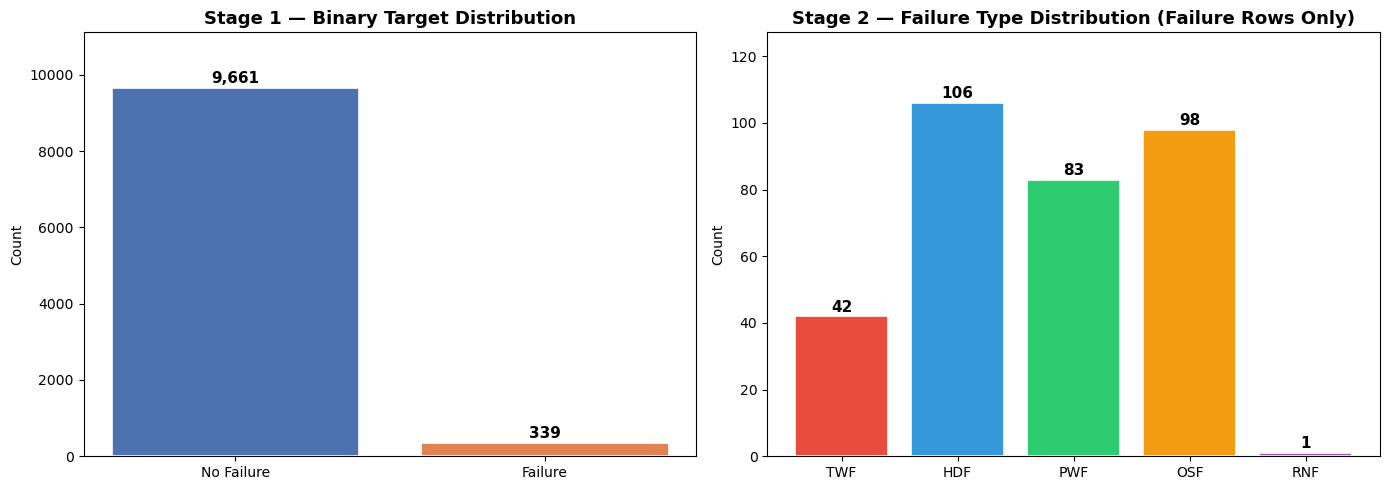

Note: Stage 1 shows extreme class imbalance → handled with SMOTE.
Stage 2 operates only on the 348 failure rows → class_weight='balanced'.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Stage 1 binary distribution ─────────────────────────────────────
ax = axes[0]
counts_bin = df['binary_target'].value_counts().sort_index()
bars = ax.bar([BINARY_LABELS[i] for i in counts_bin.index],
               counts_bin.values,
               color=['#4C72B0', '#DD8452'],
               edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts_bin.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Stage 1 — Binary Target Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count'); ax.set_ylim(0, counts_bin.max() * 1.15)

# ── Right: Stage 2 failure-type distribution ──────────────────────────────
ax = axes[1]
counts_ft = failure_df['failure_type'].value_counts().sort_index()
palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax.bar([FAILURE_LABELS[i] for i in counts_ft.index],
               counts_ft.values,
               color=palette, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts_ft.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Stage 2 — Failure Type Distribution (Failure Rows Only)', fontsize=13, fontweight='bold')
ax.set_ylabel('Count'); ax.set_ylim(0, counts_ft.max() * 1.2)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Note: Stage 1 shows extreme class imbalance → handled with SMOTE.")
print("Stage 2 operates only on the 348 failure rows → class_weight='balanced'.")

## 4. Feature Setup

In [10]:
# Full feature set (XGBoost)
ALL_FEATURES = [
    'air_temperature', 'process_temperature', 'rotational_speed',
    'torque', 'tool_wear', 'type_enc', 'temp_diff', 'power_w',
    'wear_rate', 'torque_speed_ratio', 'high_wear_flag',
    'thermal_overload', 'health_regime_enc', 'pc1', 'pc2'
]

# PCA-only features (SVM — per spec)
SVM_FEATURES = ['pc1', 'pc2']

# Keep only columns that actually exist
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f"XGBoost features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"SVM features: {SVM_FEATURES}")

XGBoost features (15): ['air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'type_enc', 'temp_diff', 'power_w', 'wear_rate', 'torque_speed_ratio', 'high_wear_flag', 'thermal_overload', 'health_regime_enc', 'pc1', 'pc2']
SVM features: ['pc1', 'pc2']


## 5. Train / Test Split

We split at the **top level** (full dataset, stratified on binary target) and propagate the same indices to Stage 2. This prevents data leakage between the two stages.

In [11]:
X_all   = df[ALL_FEATURES]
X_svm   = df[SVM_FEATURES]
y_bin   = df['binary_target']

# ── Stage 1 split ─────────────────────────────────────────────────────────
X_train_all, X_test_all, X_train_svm, X_test_svm, y_bin_train, y_bin_test, idx_train, idx_test = \
    train_test_split(
        X_all, X_svm, y_bin, df.index,
        test_size=0.2, random_state=RANDOM_STATE, stratify=y_bin
    )

# ── Stage 2 data: failure rows only ───────────────────────────────────────
# We use only TRAINING failure rows to fit Stage 2 models (no leakage)
train_df   = df.loc[idx_train]
fail_train = train_df[train_df['binary_target'] == 1]

test_df    = df.loc[idx_test]
fail_test  = test_df[test_df['binary_target'] == 1]

fail_train = fail_train.dropna(subset=['failure_type'])
fail_test  = fail_test.dropna(subset=['failure_type'])



X2_train_all = fail_train[ALL_FEATURES]
X2_train_svm = fail_train[SVM_FEATURES]
y2_train     = fail_train['failure_type'].astype(int)

X2_test_all  = fail_test[ALL_FEATURES]
X2_test_svm  = fail_test[SVM_FEATURES]
y2_test      = fail_test['failure_type'].astype(int)

print(f"Stage 1  — Train: {len(X_train_all):,} | Test: {len(X_test_all):,}")
print(f"Stage 2  — Train failure rows: {len(X2_train_all)} | Test failure rows: {len(X2_test_all)}")
print()
print("Stage 1 — test binary distribution:")
print(y_bin_test.value_counts().rename(BINARY_LABELS))
print()
print("Stage 2 — test failure-type distribution:")
print(y2_test.value_counts().sort_index().rename(FAILURE_LABELS))

Stage 1  — Train: 8,000 | Test: 2,000
Stage 2  — Train failure rows: 264 | Test failure rows: 66

Stage 1 — test binary distribution:
binary_target
No Failure    1932
Failure         68
Name: count, dtype: int64

Stage 2 — test failure-type distribution:
failure_type
TWF     9
HDF    28
PWF    13
OSF    16
Name: count, dtype: int64


## 6. SMOTE — Oversample for Stage 1

SMOTE synthesises new minority-class samples in feature space. Applied only to **training** data — never to test data.

In [12]:
smote = SMOTE(random_state=RANDOM_STATE)

# XGBoost SMOTE (full features)
X1_train_all_sm, y1_train_sm = smote.fit_resample(X_train_all, y_bin_train)

# SVM SMOTE (PCA features only)
X1_train_svm_sm, _ = smote.fit_resample(X_train_svm, y_bin_train)

print("After SMOTE — Stage 1 binary class distribution:")
unique, counts = np.unique(y1_train_sm, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {BINARY_LABELS[u]}: {c:,}")

After SMOTE — Stage 1 binary class distribution:
  No Failure: 7,729
  Failure: 7,729


---
# STAGE 1 — Binary Failure Detection
---

## 7a. XGBoost — Stage 1

In [13]:
xgb_s1 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_s1.fit(X1_train_all_sm, y1_train_sm)

y1_pred_xgb = xgb_s1.predict(X_test_all)
y1_prob_xgb = xgb_s1.predict_proba(X_test_all)[:, 1]

f1_s1_xgb  = f1_score(y_bin_test, y1_pred_xgb, average='macro')
auc_s1_xgb = roc_auc_score(y_bin_test, y1_prob_xgb)

print(f"XGBoost Stage 1  |  F1-Macro: {f1_s1_xgb:.4f}  |  ROC-AUC: {auc_s1_xgb:.4f}")
print()
print(classification_report(y_bin_test, y1_pred_xgb,
                             target_names=[BINARY_LABELS[i] for i in [0,1]]))

XGBoost Stage 1  |  F1-Macro: 0.8641  |  ROC-AUC: 0.9802

              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.68      0.81      0.74        68

    accuracy                           0.98      2000
   macro avg       0.84      0.90      0.86      2000
weighted avg       0.98      0.98      0.98      2000



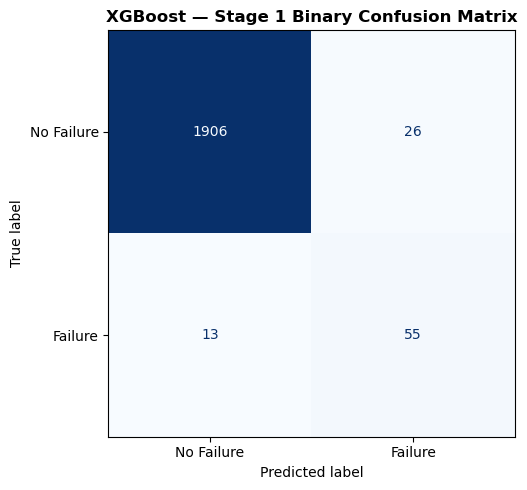

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_bin_test, y1_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('XGBoost — Stage 1 Binary Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_s1_confusion_matrix.png', dpi=150)
plt.show()

## 7b. SVM — Stage 1 (PC1 + PC2)

In [15]:
# Tune on a 30% subsample (SVM is O(n²))
X1_tune_svm, _, y1_tune_svm, _ = train_test_split(
    X1_train_svm_sm, y1_train_sm,
    train_size=0.3, stratify=y1_train_sm, random_state=RANDOM_STATE
)

param_grid_s1 = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.1, 1.0]}
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

svm_s1_search = RandomizedSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    param_grid_s1, n_iter=6, scoring='f1_macro',
    cv=cv_inner, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
svm_s1_search.fit(X1_tune_svm, y1_tune_svm)
print(f"Best SVM Stage 1 params: {svm_s1_search.best_params_}")

svm_s1 = SVC(
    kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE,
    **svm_s1_search.best_params_
)
svm_s1.fit(X1_train_svm_sm, y1_train_sm)

y1_pred_svm = svm_s1.predict(X_test_svm)
y1_prob_svm = svm_s1.predict_proba(X_test_svm)[:, 1]

f1_s1_svm  = f1_score(y_bin_test, y1_pred_svm, average='macro')
auc_s1_svm = roc_auc_score(y_bin_test, y1_prob_svm)

print(f"SVM Stage 1      |  F1-Macro: {f1_s1_svm:.4f}  |  ROC-AUC: {auc_s1_svm:.4f}")
print()
print(classification_report(y_bin_test, y1_pred_svm,
                             target_names=[BINARY_LABELS[i] for i in [0,1]]))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best SVM Stage 1 params: {'gamma': 1.0, 'C': 10}
SVM Stage 1      |  F1-Macro: 0.6028  |  ROC-AUC: 0.8642

              precision    recall  f1-score   support

  No Failure       0.99      0.86      0.92      1932
     Failure       0.17      0.84      0.28        68

    accuracy                           0.86      2000
   macro avg       0.58      0.85      0.60      2000
weighted avg       0.97      0.86      0.90      2000



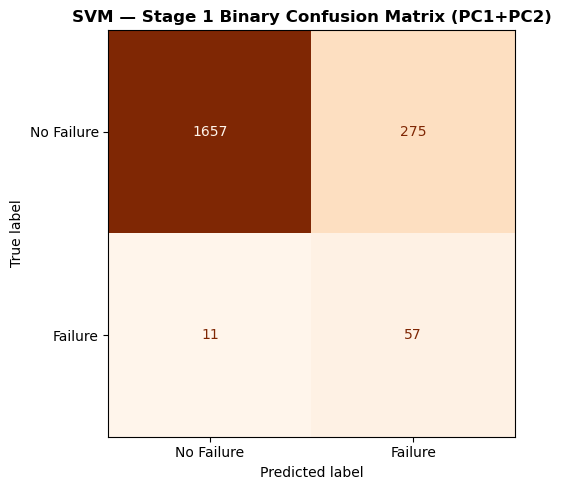

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_bin_test, y1_pred_svm)
ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure']).plot(
    ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('SVM — Stage 1 Binary Confusion Matrix (PC1+PC2)', fontweight='bold')
plt.tight_layout()
plt.savefig('svm_s1_confusion_matrix.png', dpi=150)
plt.show()

---
# STAGE 2 — Failure Type Classification
---

**Train on actual failure rows only.** Class weights handle the sub-type imbalance (RNF is rare, HDF is most common).

## 8a. XGBoost — Stage 2

In [17]:
sw_s2 = compute_sample_weight(class_weight='balanced', y=y2_train)

xgb_s2 = XGBClassifier(
    n_estimators=300,
    max_depth=4,            # shallower — small dataset (≈278 rows)
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    num_class=5,
    objective='multi:softprob',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_s2.fit(X2_train_all, y2_train, sample_weight=sw_s2)

y2_pred_xgb = xgb_s2.predict(X2_test_all)
y2_prob_xgb = xgb_s2.predict_proba(X2_test_all)

classes_s2 = sorted(y2_train.unique())
y2_test_bin = label_binarize(y2_test, classes=classes_s2)

f1_s2_xgb  = f1_score(y2_test, y2_pred_xgb, average='macro', zero_division=0)
auc_s2_xgb = roc_auc_score(y2_test_bin, y2_prob_xgb, multi_class='ovr', average='macro')

print(f"XGBoost Stage 2  |  F1-Macro: {f1_s2_xgb:.4f}  |  ROC-AUC (macro-OVR): {auc_s2_xgb:.4f}")
print()
print(classification_report(
    y2_test, y2_pred_xgb,
    labels=classes_s2,
    target_names=[FAILURE_LABELS[i] for i in classes_s2],
    zero_division=0
))

XGBoost Stage 2  |  F1-Macro: 0.9660  |  ROC-AUC (macro-OVR): nan

              precision    recall  f1-score   support

         TWF       1.00      0.89      0.94         9
         HDF       1.00      0.96      0.98        28
         PWF       1.00      1.00      1.00        13
         OSF       0.89      1.00      0.94        16
         RNF       0.00      0.00      0.00         0

    accuracy                           0.97        66
   macro avg       0.78      0.77      0.77        66
weighted avg       0.97      0.97      0.97        66



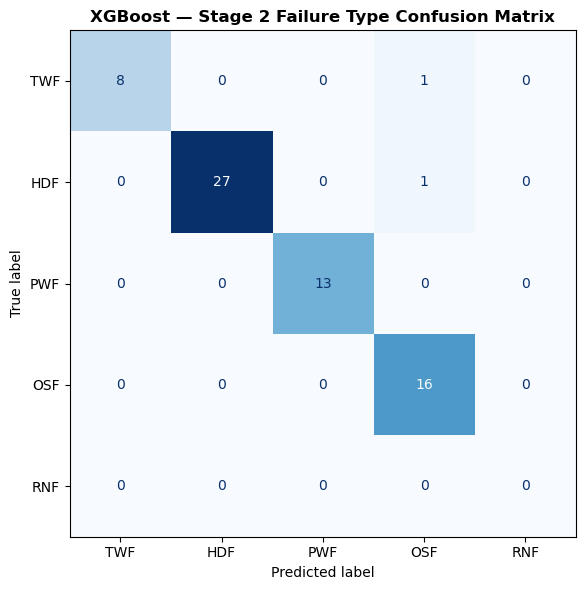

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y2_test, y2_pred_xgb, labels=classes_s2)
ConfusionMatrixDisplay(cm, display_labels=[FAILURE_LABELS[i] for i in classes_s2]).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('XGBoost — Stage 2 Failure Type Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_s2_confusion_matrix.png', dpi=150)
plt.show()

### XGBoost Stage 2 — Feature Importance

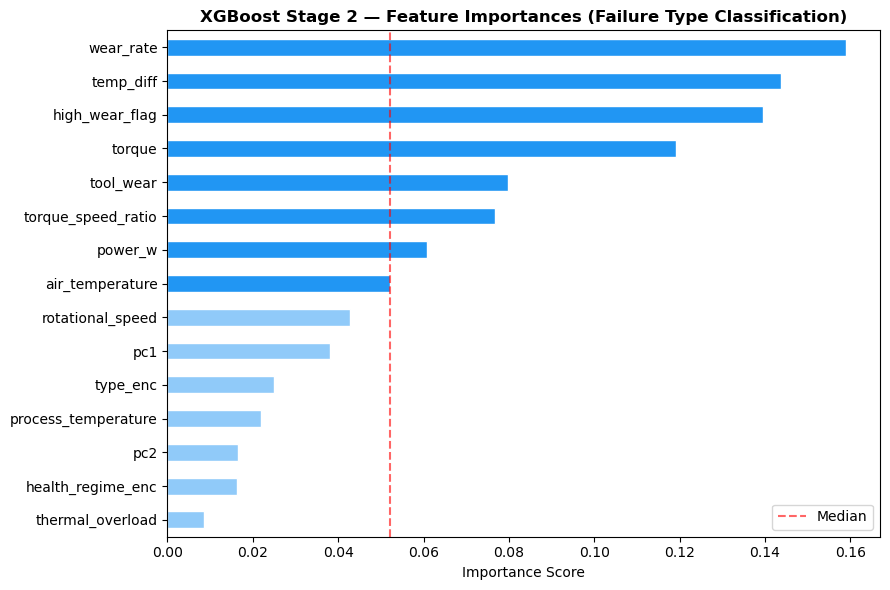

In [19]:
importances = pd.Series(
    xgb_s2.feature_importances_, index=ALL_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2196F3' if v >= importances.median() else '#90CAF9' for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(importances.median(), color='red', linestyle='--', alpha=0.6, label='Median')
ax.set_title('XGBoost Stage 2 — Feature Importances (Failure Type Classification)',
             fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

## 8b. SVM — Stage 2 (PC1 + PC2)

In [20]:
param_grid_s2 = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.1, 1.0]}

# Only ~278 training failure rows — no subsampling needed
cv_s2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

svm_s2_search = RandomizedSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    param_grid_s2, n_iter=8, scoring='f1_macro',
    cv=cv_s2, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
svm_s2_search.fit(X2_train_svm, y2_train)
print(f"Best SVM Stage 2 params: {svm_s2_search.best_params_}")

svm_s2 = SVC(
    kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE,
    **svm_s2_search.best_params_
)
svm_s2.fit(X2_train_svm, y2_train)

y2_pred_svm = svm_s2.predict(X2_test_svm)
y2_prob_svm = svm_s2.predict_proba(X2_test_svm)

f1_s2_svm  = f1_score(y2_test, y2_pred_svm, average='macro', zero_division=0)
auc_s2_svm = roc_auc_score(y2_test_bin, y2_prob_svm, multi_class='ovr', average='macro')

print(f"SVM Stage 2      |  F1-Macro: {f1_s2_svm:.4f}  |  ROC-AUC (macro-OVR): {auc_s2_svm:.4f}")
print()
print(classification_report(
    y2_test, y2_pred_svm,
    labels=classes_s2,
    target_names=[FAILURE_LABELS[i] for i in classes_s2],
    zero_division=0
))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best SVM Stage 2 params: {'gamma': 1.0, 'C': 10}
SVM Stage 2      |  F1-Macro: 0.5371  |  ROC-AUC (macro-OVR): nan

              precision    recall  f1-score   support

         TWF       1.00      0.89      0.94         9
         HDF       0.88      0.79      0.83        28
         PWF       0.43      0.69      0.53        13
         OSF       0.50      0.31      0.38        16
         RNF       0.00      0.00      0.00         0

    accuracy                           0.67        66
   macro avg       0.56      0.54      0.54        66
weighted avg       0.72      0.67      0.68        66



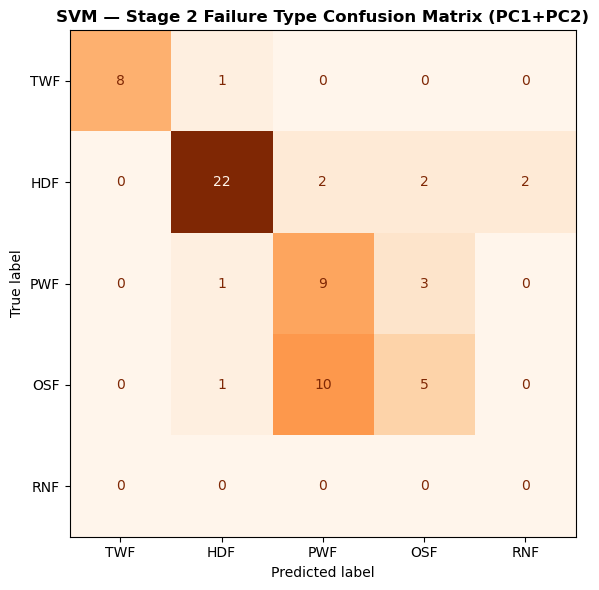

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y2_test, y2_pred_svm, labels=classes_s2)
ConfusionMatrixDisplay(cm, display_labels=[FAILURE_LABELS[i] for i in classes_s2]).plot(
    ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('SVM — Stage 2 Failure Type Confusion Matrix (PC1+PC2)', fontweight='bold')
plt.tight_layout()
plt.savefig('svm_s2_confusion_matrix.png', dpi=150)
plt.show()

### SVM Stage 2 — Decision Boundary (PC1 vs PC2)

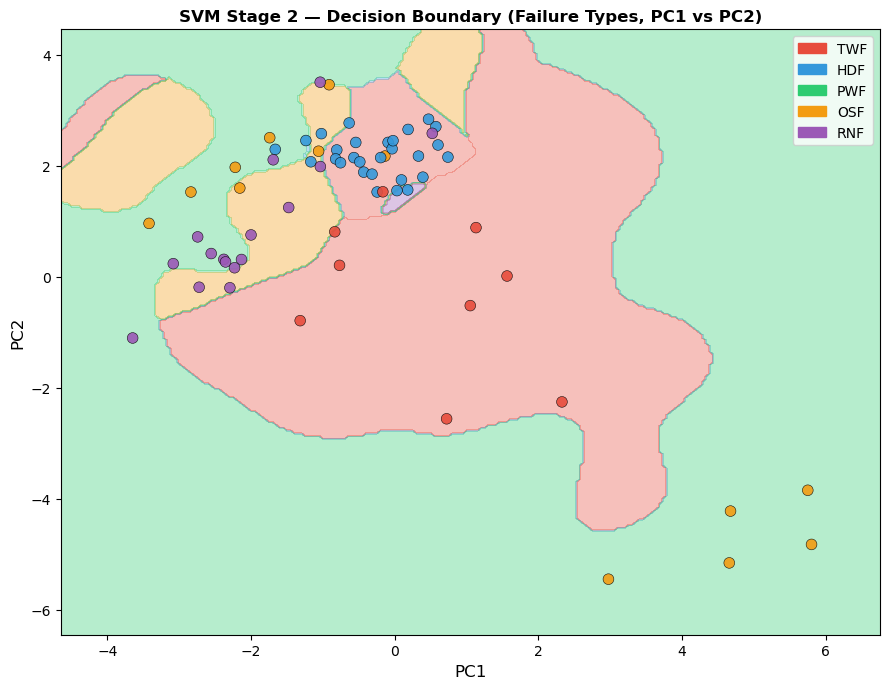

In [22]:
h = 0.05
x_min = X2_test_svm['pc1'].min() - 1; x_max = X2_test_svm['pc1'].max() + 1
y_min = X2_test_svm['pc2'].min() - 1; y_max = X2_test_svm['pc2'].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_s2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
cmap_db = plt.matplotlib.colors.ListedColormap(palette)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_db)
scatter = ax.scatter(
    X2_test_svm['pc1'], X2_test_svm['pc2'],
    c=y2_test, cmap=cmap_db,
    edgecolors='k', linewidths=0.4, s=60, alpha=0.9
)
patches = [mpatches.Patch(color=palette[i], label=FAILURE_LABELS[i]) for i in range(5)]
ax.legend(handles=patches, loc='upper right', fontsize=10)
ax.set_xlabel('PC1', fontsize=12); ax.set_ylabel('PC2', fontsize=12)
ax.set_title('SVM Stage 2 — Decision Boundary (Failure Types, PC1 vs PC2)', fontweight='bold')
plt.tight_layout()
plt.savefig('svm_decision_boundary.png', dpi=150)
plt.show()

## 9. Full Pipeline — Evaluate on Complete Test Set

In [23]:
def run_pipeline(s1_model, s2_model, X_test_full_all, X_test_full_svm,
                 y_bin_true, y_type_true_full_df, name='Pipeline'):
    """
    Evaluates the two-stage pipeline on the full test set.
    y_type_true_full_df: the full test_df with 'failure_type' column (NaN for no-failure rows)
    Returns final 6-class predictions (0=No Failure, 1=TWF, 2=HDF, 3=PWF, 4=OSF, 5=RNF)
    """
    LABEL_MAP_6 = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF', 5: 'RNF'}

    # Stage 1: predict failure / no failure
    s1_pred = s1_model.predict(X_test_full_all)

    # Stage 2: for predicted-failure rows only, predict type
    final_pred = np.zeros(len(s1_pred), dtype=int)  # default: No Failure
    fail_idx = np.where(s1_pred == 1)[0]

    if len(fail_idx) > 0:
        X_fail_all = X_test_full_all.iloc[fail_idx]
        s2_pred = s2_model.predict(X_fail_all)
        # Remap Stage 2 classes (0-4) → 6-class space (1-5)
        final_pred[fail_idx] = s2_pred + 1

    # Build ground truth in 6-class space
    # No-failure rows → 0; failure rows → failure_type + 1
    y_true_6 = np.where(
        y_bin_true.values == 0,
        0,
        y_type_true_full_df['failure_type'].fillna(-1).values + 1
    ).astype(int)
    # Rows with machine_failure=1 but no labelled type (RNF edge case) → just mark as 1 (unknown failure)
    # Here failure_type was NaN → becomes 0 in the +1 shift, so mask back to 1
    no_type_mask = (y_bin_true.values == 1) & (y_type_true_full_df['failure_type'].isna().values)
    y_true_6[no_type_mask] = 1  # fallback label

    # Macro F1 on all 6 classes
    f1_pipe = f1_score(y_true_6, final_pred, average='macro', zero_division=0)

    print(f"\n{'='*55}")
    print(f" {name} — End-to-End Results (6-class)")
    print(f"{'='*55}")
    print(f" F1-Macro (6-class): {f1_pipe:.4f}")
    print()
    print(classification_report(
        y_true_6, final_pred,
        labels=[0,1,2,3,4,5],
        target_names=[LABEL_MAP_6[i] for i in range(6)],
        zero_division=0
    ))

    return final_pred, y_true_6, f1_pipe


# XGBoost end-to-end pipeline
xgb_final_pred, y_true_6, f1_xgb_pipe = run_pipeline(
    xgb_s1, xgb_s2,
    X_test_all, X_test_svm,
    y_bin_test, test_df,
    name='XGBoost Pipeline'
)


 XGBoost Pipeline — End-to-End Results (6-class)
 F1-Macro (6-class): 0.7169

              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
         TWF       0.09      0.09      0.09        11
         HDF       0.89      0.89      0.89        28
         PWF       0.81      1.00      0.90        13
         OSF       0.58      0.94      0.71        16
         RNF       0.00      0.00      0.00         0

    accuracy                           0.98      2000
   macro avg       0.56      0.65      0.60      2000
weighted avg       0.98      0.98      0.98      2000



In [24]:
LABEL_MAP_6 = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF', 5: 'RNF'}

# SVM end-to-end pipeline (SVM uses pca features for both stages)
def run_svm_pipeline(s1_model, s2_model, X_test_svm_full, y_bin_true, test_df_full, name='SVM Pipeline'):
    s1_pred = s1_model.predict(X_test_svm_full)
    final_pred = np.zeros(len(s1_pred), dtype=int)
    fail_idx = np.where(s1_pred == 1)[0]
    if len(fail_idx) > 0:
        X_fail_svm = X_test_svm_full.iloc[fail_idx]
        s2_pred = s2_model.predict(X_fail_svm)
        final_pred[fail_idx] = s2_pred + 1

    y_true_6 = np.where(
        y_bin_true.values == 0, 0,
        test_df_full['failure_type'].fillna(-1).values + 1
    ).astype(int)
    no_type_mask = (y_bin_true.values == 1) & (test_df_full['failure_type'].isna().values)
    y_true_6[no_type_mask] = 1

    f1_pipe = f1_score(y_true_6, final_pred, average='macro', zero_division=0)

    print(f"\n{'='*55}")
    print(f" {name} — End-to-End Results (6-class)")
    print(f"{'='*55}")
    print(f" F1-Macro (6-class): {f1_pipe:.4f}")
    print()
    print(classification_report(
        y_true_6, final_pred,
        labels=[0,1,2,3,4,5],
        target_names=[LABEL_MAP_6[i] for i in range(6)],
        zero_division=0
    ))
    return final_pred, y_true_6, f1_pipe


svm_final_pred, _, f1_svm_pipe = run_svm_pipeline(
    svm_s1, svm_s2, X_test_svm, y_bin_test, test_df, name='SVM Pipeline'
)


 SVM Pipeline — End-to-End Results (6-class)
 F1-Macro (6-class): 0.2504

              precision    recall  f1-score   support

  No Failure       0.99      0.86      0.92      1932
         TWF       0.00      0.00      0.00        11
         HDF       0.13      0.79      0.23        28
         PWF       0.16      0.69      0.26        13
         OSF       0.06      0.31      0.10        16
         RNF       0.00      0.00      0.00         0

    accuracy                           0.85      2000
   macro avg       0.22      0.44      0.25      2000
weighted avg       0.96      0.85      0.89      2000



## 10. End-to-End Confusion Matrices (6-class)

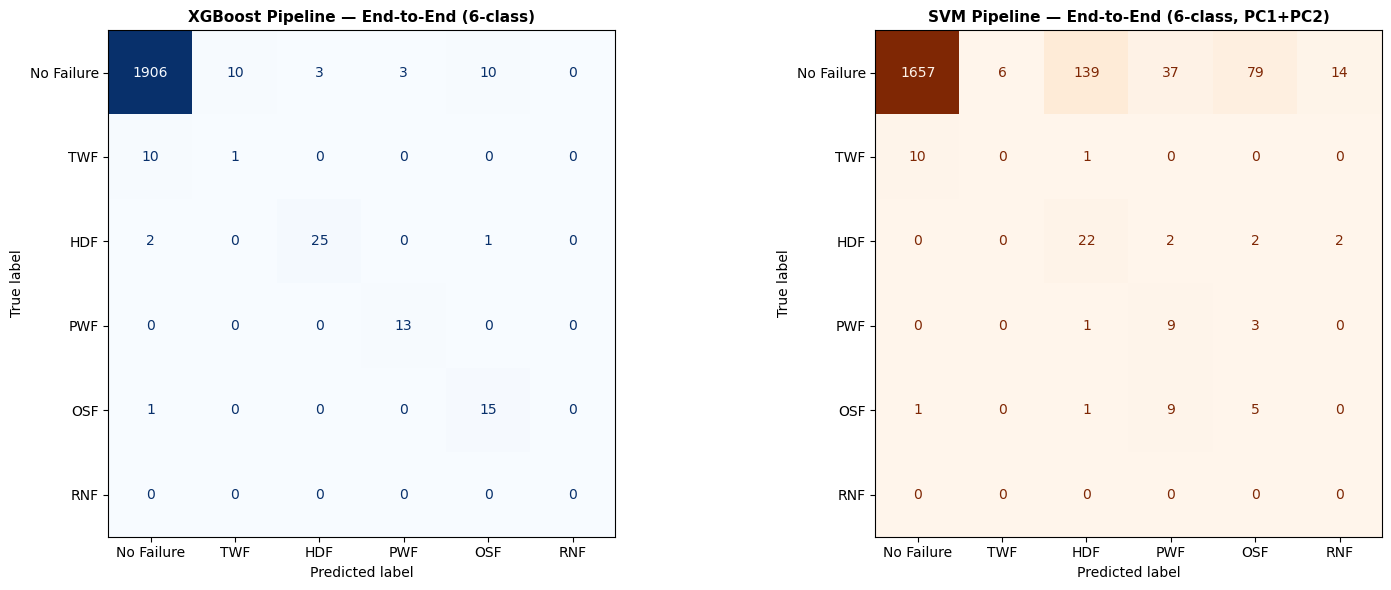

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_names_6 = [LABEL_MAP_6[i] for i in range(6)]

for ax, pred, cmap, title in zip(
    axes,
    [xgb_final_pred, svm_final_pred],
    ['Blues', 'Oranges'],
    ['XGBoost Pipeline — End-to-End (6-class)',
     'SVM Pipeline — End-to-End (6-class, PC1+PC2)']
):
    cm = confusion_matrix(y_true_6, pred, labels=list(range(6)))
    ConfusionMatrixDisplay(cm, display_labels=class_names_6).plot(
        ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title, fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('pipeline_confusion_matrices.png', dpi=150)
plt.show()

## 11. Model Comparison Summary

In [26]:
summary = pd.DataFrame({
    'Model': [
        'XGBoost (Stage 1 — Binary)',
        'SVM RBF (Stage 1 — Binary, PC1+PC2)',
        'XGBoost (Stage 2 — Failure Type)',
        'SVM RBF (Stage 2 — Failure Type, PC1+PC2)',
        'XGBoost Full Pipeline (6-class)',
        'SVM Full Pipeline (6-class, PC1+PC2)',
    ],
    'F1-Macro': [
        f1_s1_xgb, f1_s1_svm,
        f1_s2_xgb, f1_s2_svm,
        f1_xgb_pipe, f1_svm_pipe
    ],
    'ROC-AUC': [
        auc_s1_xgb, auc_s1_svm,
        auc_s2_xgb, auc_s2_svm,
        None, None
    ]
})
summary['F1-Macro'] = summary['F1-Macro'].round(4)
summary['ROC-AUC'] = summary['ROC-AUC'].round(4)
print(summary.to_string(index=False))

                                    Model  F1-Macro  ROC-AUC
               XGBoost (Stage 1 — Binary)    0.8641   0.9802
      SVM RBF (Stage 1 — Binary, PC1+PC2)    0.6028   0.8642
         XGBoost (Stage 2 — Failure Type)    0.9660      NaN
SVM RBF (Stage 2 — Failure Type, PC1+PC2)    0.5371      NaN
          XGBoost Full Pipeline (6-class)    0.7169      NaN
     SVM Full Pipeline (6-class, PC1+PC2)    0.2504      NaN


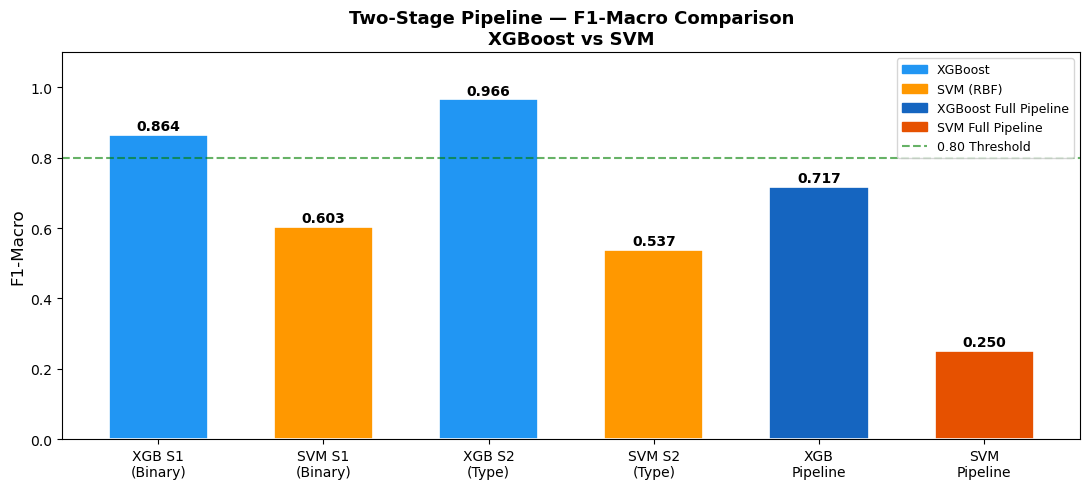

In [27]:


fig, ax = plt.subplots(figsize=(11, 5))

# Labels
models_short = [
    'XGB S1\n(Binary)', 'SVM S1\n(Binary)',
    'XGB S2\n(Type)', 'SVM S2\n(Type)',
    'XGB\nPipeline', 'SVM\nPipeline'
]

# Values
f1_vals = summary['F1-Macro'].tolist()

# Colors
colors = ['#2196F3','#FF9800','#2196F3','#FF9800','#1565C0','#E65100']

# Bar plot
bars = ax.bar(models_short, f1_vals, color=colors,
              edgecolor='white', linewidth=1.2, width=0.6)

# Value labels on bars
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Axis styling
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-Macro', fontsize=12)
ax.set_title('Two-Stage Pipeline — F1-Macro Comparison\nXGBoost vs SVM',
             fontweight='bold', fontsize=13)

# Threshold line
line = ax.axhline(0.8, color='green', linestyle='--', alpha=0.6)

# Legend (FIXED)
legend_handles = [
    mpatches.Patch(color='#2196F3', label='XGBoost'),
    mpatches.Patch(color='#FF9800', label='SVM (RBF)'),
    mpatches.Patch(color='#1565C0', label='XGBoost Full Pipeline'),
    mpatches.Patch(color='#E65100', label='SVM Full Pipeline'),
    line
]

legend_labels = [
    'XGBoost',
    'SVM (RBF)',
    'XGBoost Full Pipeline',
    'SVM Full Pipeline',
    '0.80 Threshold'
]

ax.legend(handles=legend_handles, labels=legend_labels,
          loc='upper right', fontsize=9)

# Final layout
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 12. Cross-Validation — Stability Check

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score
from sklearn.svm import SVC

# ── CV setup ──────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# =========================
# 🔵 XGBOOST
# =========================

# ── Stage 1: Binary ───────────────────────────────────────────────────────
xgb_s1 = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1
)

xgb_s1_scores = cross_val_score(
    xgb_s1, X1_train_all_sm, y1_train_sm,
    cv=cv, scoring='f1_macro', n_jobs=-1
)

# ── Stage 2: Multiclass (manual CV with weights) ──────────────────────────
xgb_s2 = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss',
    objective='multi:softprob',
    num_class=len(np.unique(y2_train)),
    random_state=RANDOM_STATE, n_jobs=-1
)

xgb_s2_scores = []

for train_idx, val_idx in cv.split(X2_train_all, y2_train):
    X_tr, X_val = X2_train_all.iloc[train_idx], X2_train_all.iloc[val_idx]
    y_tr, y_val = y2_train.iloc[train_idx], y2_train.iloc[val_idx]

    # compute weights per fold
    sw = compute_sample_weight(class_weight='balanced', y=y_tr)

    xgb_s2.fit(X_tr, y_tr, sample_weight=sw)
    y_pred = xgb_s2.predict(X_val)

    score = f1_score(y_val, y_pred, average='macro')
    xgb_s2_scores.append(score)

xgb_s2_scores = np.array(xgb_s2_scores)

# =========================
# 🟠 SVM
# =========================

# ── Stage 1: Binary ───────────────────────────────────────────────────────
svm_s1 = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=RANDOM_STATE
)

svm_s1_scores = cross_val_score(
    svm_s1, X1_train_all_sm, y1_train_sm,
    cv=cv, scoring='f1_macro', n_jobs=-1
)

# ── Stage 2: Multiclass ───────────────────────────────────────────────────
svm_s2 = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    decision_function_shape='ovr',
    random_state=RANDOM_STATE
)

svm_s2_scores = cross_val_score(
    svm_s2, X2_train_all, y2_train,
    cv=cv, scoring='f1_macro', n_jobs=-1
)

# =========================
# 📊 RESULTS
# =========================

print("===== CROSS-VALIDATION RESULTS (F1-MACRO) =====\n")

print(f"XGBoost Stage 1 (Binary):   {xgb_s1_scores.mean():.4f} ± {xgb_s1_scores.std():.4f}")
print(f"XGBoost Stage 2 (Type):     {xgb_s2_scores.mean():.4f} ± {xgb_s2_scores.std():.4f}\n")

print(f"SVM Stage 1 (Binary):       {svm_s1_scores.mean():.4f} ± {svm_s1_scores.std():.4f}")
print(f"SVM Stage 2 (Type):         {svm_s2_scores.mean():.4f} ± {svm_s2_scores.std():.4f}")

===== CROSS-VALIDATION RESULTS (F1-MACRO) =====

XGBoost Stage 1 (Binary):   0.9890 ± 0.0018
XGBoost Stage 2 (Type):     0.9282 ± 0.0787

SVM Stage 1 (Binary):       0.7807 ± 0.0082
SVM Stage 2 (Type):         0.3817 ± 0.0595


In [29]:
from sklearn.metrics import accuracy_score


# Accuracy (6-class final pipeline)
xgb_acc = accuracy_score(y_true_6, xgb_final_pred)
svm_acc = accuracy_score(y_true_6, svm_final_pred)

print("\n" + "=" * 60)
print("  FINAL RESULTS SUMMARY (PIPELINE)")
print("=" * 60)

summary = pd.DataFrame({
    "Model": ["XGBoost Pipeline", "SVM Pipeline"],
    "Accuracy": [round(xgb_acc, 4), round(svm_acc, 4)],
    "F1-macro": [round(f1_xgb_pipe, 4), round(f1_svm_pipe, 4)],
})

print(summary.to_string(index=False))

# Best model based on F1 (most important for imbalance)
winner = "XGBoost Pipeline" if f1_xgb_pipe >= f1_svm_pipe else "SVM Pipeline"

print(f"\n Best model by F1-macro: {winner}")
print("=" * 60)


  FINAL RESULTS SUMMARY (PIPELINE)
           Model  Accuracy  F1-macro
XGBoost Pipeline    0.9800    0.7169
    SVM Pipeline    0.8465    0.2504

 Best model by F1-macro: XGBoost Pipeline


In [30]:
import joblib

# ===== Save SVM models =====
joblib.dump(svm_s1, "svm_s1.pkl")
joblib.dump(svm_s2, "svm_s2.pkl")

# ===== Save XGBoost models =====
joblib.dump(xgb_s1, "xgb_s1.pkl")
joblib.dump(xgb_s2, "xgb_s2.pkl")

print("All models saved successfully")

All models saved successfully
